# Predicción de rendimientos de bonos del Tesoro de EE.UU.
### Indicadores técnicos + modelos secuenciales (RNN / LSTM / GRU)

**Contexto breve**
- Objetivo: reconstruir la curva completa de rendimientos del Tesoro de EE.UU. (8 plazos, de 3 meses a 30 años) a partir de indicadores macroeconómicos y del comportamiento reciente de cada serie.
- Enfoque: selección de variables por información mutua, prueba de estacionariedad (ADF) + diferenciación, indicadores técnicos (SMA, Bandas de Bollinger, RSI, autocorrelación) y un modelo secuencial por plazo.
- **El dataset de este notebook es sintético**, construido para replicar la estructura y el comportamiento de una curva de rendimientos real, sin usar datos de ningún cliente. Sirve para demostrar el pipeline completo, no para replicar cifras reales de mercado.
- Artículo completo, con el diagrama interactivo y las ecuaciones de cada indicador: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-rendimientos-bonos-tesoro-eeuu-indicadores-tecnicos/


## 0. Pipeline de la solución

- **Fuentes**: indicadores macroeconómicos + curva de rendimientos (8 plazos)
- **Selección de variables**: información mutua sobre las variables macro
- **Estacionariedad**: prueba ADF + diferenciación de primer orden
- **Indicadores técnicos**: SMA, Bandas de Bollinger, RSI, autocorrelación lag-1 (ver ecuaciones en el artículo)
- **Escalamiento**: StandardScaler por variable
- **Modelos**: RNN / LSTM / GRU entrenados por separado para cada plazo
- **Salida**: predicción de la curva completa de rendimientos

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Dataset sintético: `outputs/rendimientos_bonos_sintetico.csv`
- Contiene 14 indicadores macro sintéticos + 8 series de rendimiento (3M a 30Y)
- Frecuencia diaria (días hábiles), ~4.8 años de historia reducida para fines de demostración


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('outputs/rendimientos_bonos_sintetico.csv')
dataset['Fecha'] = pd.to_datetime(dataset['Fecha'])
dataset = dataset.sort_values('Fecha').reset_index(drop=True)

print(f'El dataset (sintético) tiene {dataset.shape[1]} variables y {dataset.shape[0]} registros.')
print('Fecha más antigua:', dataset['Fecha'].min().date())
print('Fecha más reciente:', dataset['Fecha'].max().date())
dataset.head(3)


El dataset (sintético) tiene 23 variables y 1200 registros.
Fecha más antigua: 2019-01-02
Fecha más reciente: 2023-08-08


,Fecha,PCE CYOY Index,CPI XYOY Index,IPC services - CSXHSPCY Index,Salarios - AHE YOY Index,Unit Labor Cost - COSTNFR Index,Nominas - NFP TCH Index,Tasa de desempleo - USURTOT Index,ISM servicios - NAPMNMI Index,ISM Manuf - NAPMPMI Index,...,GDP Real YoY - EHGDUSY Index,Foreign holdings - FARBTRSE Index,USGG3M Index,USGG6M Index,USGG12M Index,USGG2Y Index,USGG3Y Index,USGG5Y Index,USGG10Y Index,USGG30Y Index
0,2019-01-02,-0.030890,0.393052,0.365194,0.071182,-0.151891,-0.327015,-0.124473,0.162594,0.172713,...,-0.162583,0.202856,1.486256,1.598272,1.713151,1.903916,2.092258,2.391044,2.691586,2.989958
1,2019-01-03,0.011740,0.240592,0.153389,-0.016963,-0.092326,-0.175024,-0.296644,0.180975,0.310057,...,-0.121073,0.166272,1.499681,1.582381,1.707723,1.873780,2.068148,2.355289,2.618644,2.945395
2,2019-01-04,-0.112611,0.127476,0.277501,-0.115830,-0.214544,-0.319334,-0.013082,0.313697,0.248062,...,-0.037353,-0.054289,1.487531,1.561286,1.702197,1.914967,2.081795,2.398154,2.641229,2.973739


## 2. Explicación de los datos

- Las columnas `USGG{plazo} Index` representan el rendimiento sintético para cada plazo de la curva
- Las columnas macro son indicadores sintéticos análogos en espíritu a inflación, empleo, actividad manufacturera, tenencia extranjera de deuda, etc.
- Todas las series son continuas y numéricas, sin variables categóricas


In [2]:
yields = [c for c in dataset.columns if c.startswith('USGG')]
macro_vars = [c for c in dataset.columns if c not in yields + ['Fecha']]

print(f'{len(yields)} plazos de la curva:', yields)
print(f'{len(macro_vars)} variables macro sintéticas')
dataset[yields].describe().T[['mean', 'std', 'min', 'max']]


8 plazos de la curva: ['USGG3M Index', 'USGG6M Index', 'USGG12M Index', 'USGG2Y Index', 'USGG3Y Index', 'USGG5Y Index', 'USGG10Y Index', 'USGG30Y Index']
14 variables macro sintéticas


,mean,std,min,max
USGG3M Index,1.326569,0.192265,0.895082,1.723349
USGG6M Index,1.327716,0.186482,0.834376,1.730394
USGG12M Index,1.416402,0.159099,1.018613,1.761513
USGG2Y Index,1.214928,0.567252,0.050000,2.197771
USGG3Y Index,1.767700,0.263415,1.098445,2.227787
USGG5Y Index,2.213272,0.233669,1.642673,2.745260
USGG10Y Index,1.835623,0.462443,1.026007,2.803752
USGG30Y Index,2.285898,0.409920,1.660011,3.183988


## 3. Análisis exploratorio (EDA)

- Curva de rendimientos en una fecha específica, para verificar que la forma sea razonable (ascendente de corto a largo plazo)
- Información mutua entre variables macro y rendimientos, para anticipar la selección de variables del paso de modelado


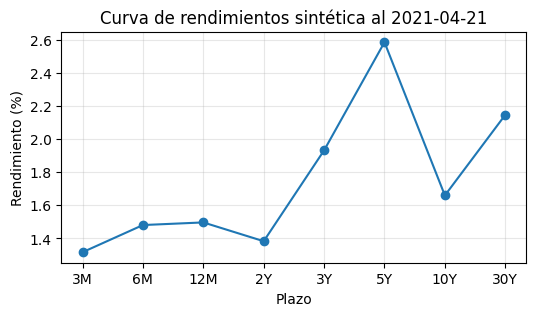

In [3]:
import matplotlib.pyplot as plt

fecha_ejemplo = dataset['Fecha'].iloc[600]
fila = dataset[dataset['Fecha'] == fecha_ejemplo][yields].T
fila.columns = ['Rendimiento']
labels = ['3M', '6M', '12M', '2Y', '3Y', '5Y', '10Y', '30Y']

plt.figure(figsize=(6, 3))
plt.plot(labels, fila['Rendimiento'], marker='o')
plt.title(f'Curva de rendimientos sintética al {fecha_ejemplo.date()}')
plt.xlabel('Plazo')
plt.ylabel('Rendimiento (%)')
plt.grid(alpha=0.3)
plt.show()


In [4]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

X = dataset[macro_vars].values
X_scaled = StandardScaler().fit_transform(X)

mi_scores = []
for y_col in yields:
    mi = mutual_info_regression(X_scaled, dataset[y_col].values, random_state=42)
    mi_scores.append(mi)

mi_avg = np.mean(mi_scores, axis=0)
mi_df = pd.DataFrame({'variable': macro_vars, 'info_mutua_promedio': mi_avg}).sort_values(
    'info_mutua_promedio', ascending=False)

top_features = mi_df.head(8)['variable'].tolist()
mi_df.head(8)


,variable,info_mutua_promedio
5,Nominas - NFP TCH Index,0.302480
13,Foreign holdings - FARBTRSE Index,0.275536
7,ISM servicios - NAPMNMI Index,0.262881
12,GDP Real YoY - EHGDUSY Index,0.254722
8,ISM Manuf - NAPMPMI Index,0.239749
6,Tasa de desempleo - USURTOT Index,0.205834
9,ISM prices paid - NAPMNPRC Index,0.186159
3,Salarios - AHE YOY Index,0.183667


## 4. Modelado

- Prueba de estacionariedad (ADF) sobre cada rendimiento y diferenciación de primer orden
- Cálculo de indicadores técnicos (SMA, Bandas de Bollinger, RSI, autocorrelación lag-1) sobre la serie diferenciada
- Entrenamiento de un modelo GRU por plazo (aquí se muestra el flujo completo para dos plazos, 3M y 10Y, como demostración; el proyecto completo repite el mismo proceso para los 8 plazos y compara RNN, LSTM y GRU)


In [5]:
from statsmodels.tsa.stattools import adfuller

def calculate_technical_indicators(serie, window=10):
    df_ind = pd.DataFrame({'valor': serie})
    df_ind['SMA'] = df_ind['valor'].rolling(window).mean()
    rolling_mean = df_ind['valor'].rolling(window).mean()
    rolling_std = df_ind['valor'].rolling(window).std()
    df_ind['BB_upper'] = rolling_mean + rolling_std
    df_ind['BB_lower'] = rolling_mean - rolling_std
    delta = df_ind['valor'].diff()
    gain = delta.where(delta > 0, 0).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    RS = gain / loss
    df_ind['RSI'] = 100 - (100 / (1 + RS))
    df_ind['lag_1'] = df_ind['valor'].shift(1)
    return df_ind.dropna()

for target in ['USGG3M Index', 'USGG10Y Index']:
    p_value = adfuller(dataset[target])[1]
    print(f'{target}: p-value ADF = {p_value:.4f} -> {"estacionaria" if p_value < 0.05 else "NO estacionaria, se diferencia"}')


USGG3M Index: p-value ADF = 0.2109 -> NO estacionaria, se diferencia
USGG10Y Index: p-value ADF = 0.4874 -> NO estacionaria, se diferencia


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

tf.random.set_seed(42)
resultados = {}
predicciones = {}

for target in ['USGG3M Index', 'USGG10Y Index']:
    serie_dif = dataset[target].diff().dropna()
    ind = calculate_technical_indicators(serie_dif)

    X = ind[['SMA', 'BB_upper', 'BB_lower', 'RSI', 'lag_1']].values
    y = ind['valor'].values

    scaler_X, scaler_y = StandardScaler(), StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    n_test = 120
    X_train, X_test = X_scaled[:-n_test], X_scaled[-n_test:]
    y_train, y_test = y_scaled[:-n_test], y_scaled[-n_test:]

    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    model = Sequential([
        GRU(32, return_sequences=False, input_shape=(1, X_train.shape[2])),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    model.fit(X_train, y_train, epochs=15, batch_size=16, verbose=0, validation_data=(X_test, y_test))

    pred_scaled = model.predict(X_test, verbose=0).ravel()
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    resultados[target] = {
        'mse': mean_squared_error(real, pred),
        'mae': mean_absolute_error(real, pred),
        'r2': r2_score(real, pred),
    }
    predicciones[target] = {'real': real, 'pred': pred}

print('Entrenamiento GRU completado para', list(resultados.keys()))


I0000 00:00:1785458109.399462    1909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785458109.451208    1909 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785458111.351385    1909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenamiento GRU completado para ['USGG3M Index', 'USGG10Y Index']


## 5. Evaluación

- Métricas de error (MSE, MAE, R2) por plazo sobre el conjunto de prueba (últimos 120 registros)
- Comparación visual entre el cambio real y el predicho por el GRU


In [7]:
pd.DataFrame(resultados).T


,mse,mae,r2
USGG3M Index,0.000215,0.011869,0.596991
USGG10Y Index,0.000369,0.015562,0.536244


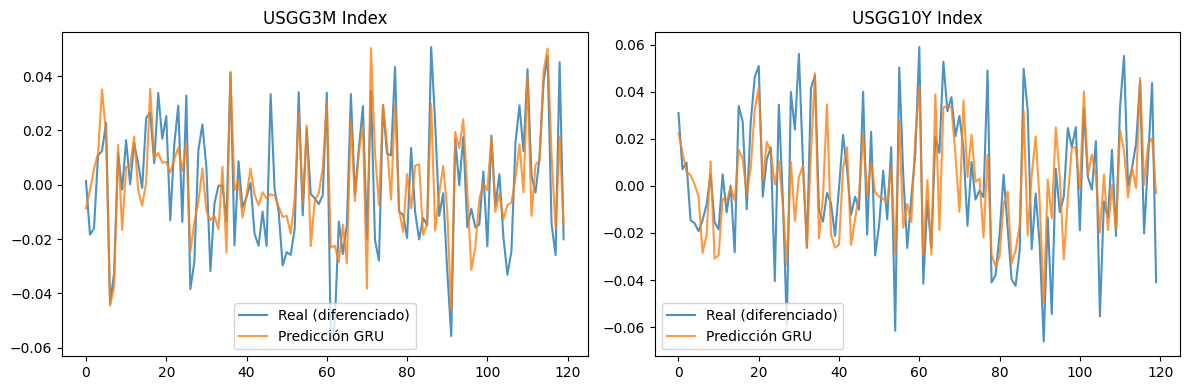

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, target in zip(axs, resultados.keys()):
    ax.plot(predicciones[target]['real'], label='Real (diferenciado)', alpha=0.8)
    ax.plot(predicciones[target]['pred'], label='Predicción GRU', alpha=0.8)
    ax.set_title(target)
    ax.legend()
plt.tight_layout()
plt.show()


## Hallazgos principales

- La selección de variables por información mutua y la corrección de estacionariedad (ADF + diferenciación) fueron pasos obligatorios antes de que cualquier modelo secuencial tuviera sentido.
- Los indicadores técnicos (SMA, Bandas de Bollinger, RSI, autocorrelación) le dieron al modelo una señal de momentum y volatilidad que el nivel crudo del rendimiento no tenía.
- En este demo con datos sintéticos, el plazo corto (3M) es visiblemente más fácil de aproximar que el plazo largo (10Y), consistente con lo observado en el proyecto completo: los plazos largos incorporan expectativas de política monetaria y factores macro que ninguna variable del dataset captura del todo.
- Este notebook no debe interpretarse como una predicción real de mercado; usa datos sintéticos y una versión reducida del pipeline completo, pensada para demostrar el enfoque.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-rendimientos-bonos-tesoro-eeuu-indicadores-tecnicos/
